In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
vocab_size = 10000  # top 10k words

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 25000
Testing samples: 25000


In [3]:
max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

In [5]:
model = Sequential()

# Embedding Layer
model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))

# LSTM Layer
model.add(LSTM(64))

# Output Layer
model.add(Dense(1, activation='sigmoid'))



In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 85ms/step - accuracy: 0.7958 - loss: 0.4330 - val_accuracy: 0.8308 - val_loss: 0.4105
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.8953 - loss: 0.2700 - val_accuracy: 0.8640 - val_loss: 0.3260
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.9260 - loss: 0.1959 - val_accuracy: 0.8622 - val_loss: 0.3320
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.9513 - loss: 0.1348 - val_accuracy: 0.8690 - val_loss: 0.3976
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9604 - loss: 0.1083 - val_accuracy: 0.8676 - val_loss: 0.4678


In [8]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8564 - loss: 0.5008
Test Accuracy: 0.8564000129699707


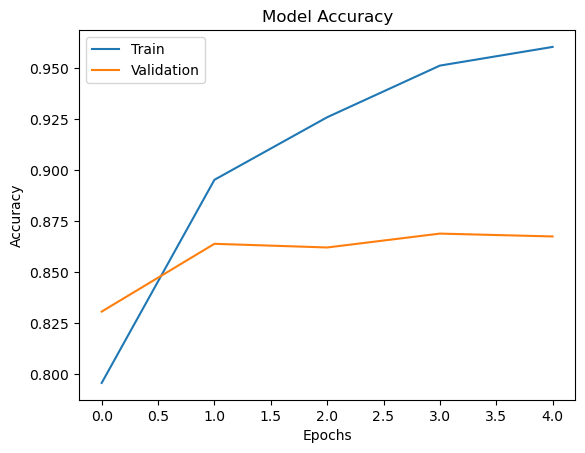

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Validation'])

plt.show()